# Detect Sound Units
Loads the synthesized audio and automatically finds where each sound unit begins and ends.
See `docs/detect_units.md` for theory.

## Imports

In [2]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import Audio, display
import json

print('ready')

ready


## Load the audio file

In [3]:
sample_rate, data = wav.read('../audio/rocky_voice.wav')

# convert int16 back to float in range [-1, 1]
audio = data.astype(np.float64) / 32767.0

duration = len(audio) / sample_rate
print(f'sample rate : {sample_rate} Hz')
print(f'samples     : {len(audio):,}')
print(f'duration    : {duration:.2f}s')
display(Audio(audio, rate=sample_rate))

sample rate : 44100 Hz
samples     : 2,932,864
duration    : 66.50s


## Compute RMS energy over time
Slide a short window across the audio and measure loudness at each position.

In [4]:
WINDOW  = 512   # samples per window (~11ms at 44100 Hz)
HOP     = 128   # step between windows (~3ms) — overlap gives smoother curve

def compute_rms(audio, window, hop):
    frames = []
    for i in range(0, len(audio) - window, hop):
        frame = audio[i : i + window]
        rms = np.sqrt(np.mean(frame ** 2))  # root mean square = loudness
        frames.append(rms)
    return np.array(frames)

rms = compute_rms(audio, WINDOW, HOP)

# time axis for plotting
rms_times = np.arange(len(rms)) * HOP / sample_rate

print(f'RMS frames computed: {len(rms)}')
print(f'each frame covers  : {HOP/sample_rate*1000:.1f}ms')

RMS frames computed: 22909
each frame covers  : 2.9ms


## Compute onset strength
How sharply does the energy rise at each frame? A sudden rise = a new sound starting.

In [5]:
# onset strength = positive differences in RMS (only rising edges)
onset_strength = np.diff(rms, prepend=rms[0])
onset_strength = np.clip(onset_strength, 0, None)  # keep only rises, zero out falls

print(f'max onset strength : {onset_strength.max():.4f}')
print(f'mean onset strength: {onset_strength.mean():.4f}')

max onset strength : 0.3436
mean onset strength: 0.0073


## Find onset peaks — where new sounds begin

In [6]:
from scipy.signal import find_peaks

THRESHOLD    = onset_strength.max() * 0.15  # minimum height to count as onset
MIN_GAP_SEC  = 0.05                          # minimum seconds between two onsets
MIN_GAP_FRAMES = int(MIN_GAP_SEC * sample_rate / HOP)

peaks, _ = find_peaks(onset_strength, height=THRESHOLD, distance=MIN_GAP_FRAMES)

onset_times = rms_times[peaks]  # convert frame indices to seconds

print(f'onsets detected : {len(peaks)}')
print(f'onset times (s) : {[round(t, 3) for t in onset_times]}')

onsets detected : 272
onset times (s) : [np.float64(0.102), np.float64(0.223), np.float64(0.551), np.float64(0.772), np.float64(1.309), np.float64(1.672), np.float64(1.791), np.float64(1.913), np.float64(2.148), np.float64(2.781), np.float64(3.007), np.float64(3.242), np.float64(3.556), np.float64(3.666), np.float64(3.776), np.float64(4.304), np.float64(4.365), np.float64(4.432), np.float64(4.583), np.float64(4.897), np.float64(5.03), np.float64(5.3), np.float64(6.078), np.float64(6.319), np.float64(6.647), np.float64(7.024), np.float64(7.242), np.float64(7.369), np.float64(8.13), np.float64(8.258), np.float64(8.992), np.float64(9.355), np.float64(9.465), np.float64(10.005), np.float64(10.089), np.float64(10.144), np.float64(10.234), np.float64(10.376), np.float64(10.995), np.float64(11.111), np.float64(11.645), np.float64(12.031), np.float64(12.124), np.float64(12.19), np.float64(12.309), np.float64(12.379), np.float64(12.469), np.float64(12.559), np.float64(13.09), np.float64(13.157)

## Visualize — waveform with detected onsets marked

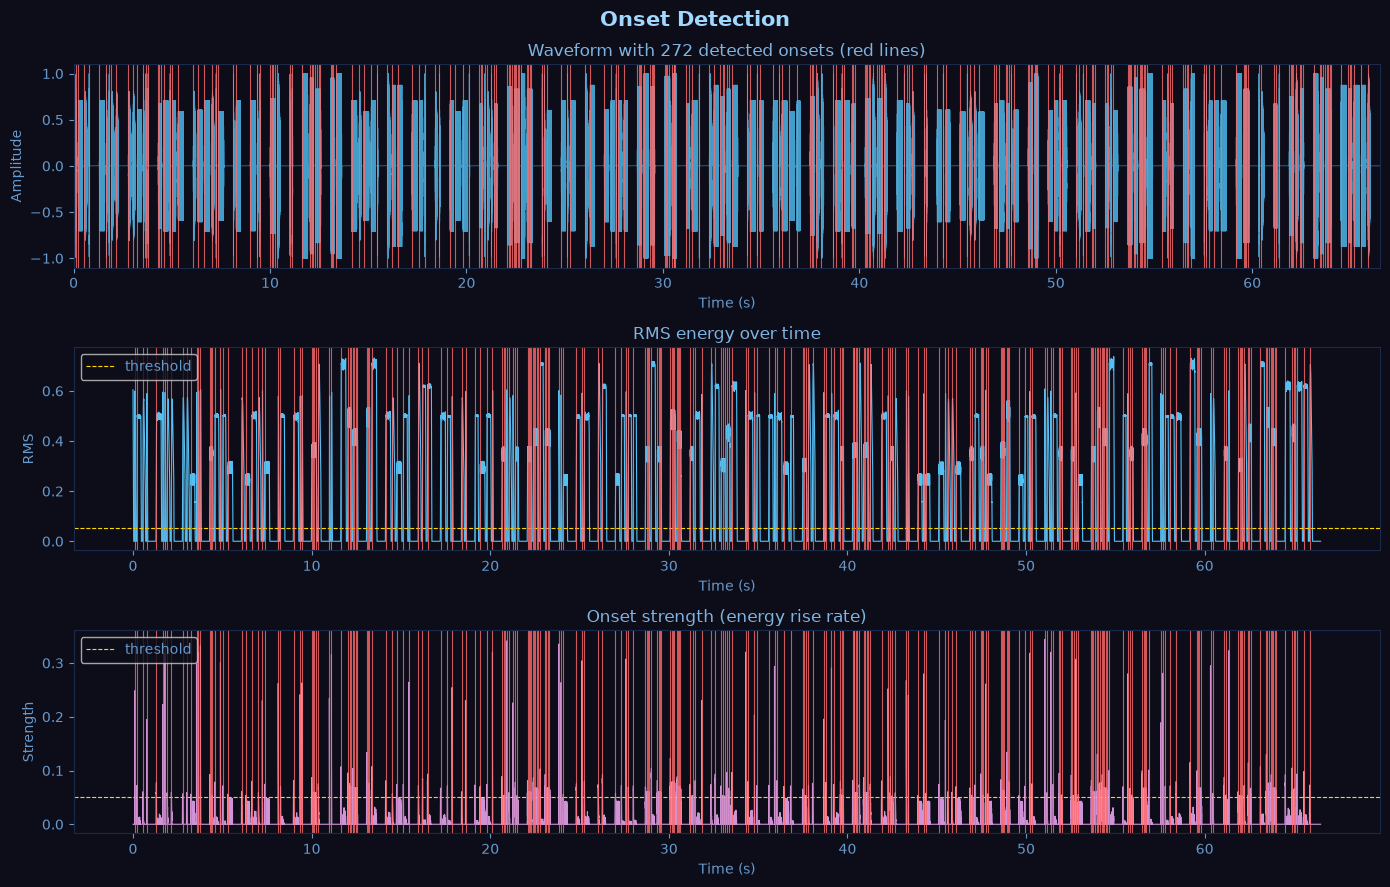

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), facecolor='#0d0d1a')
fig.suptitle("Onset Detection", color='#a0d8ff', fontsize=15, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='#6699cc')
    ax.xaxis.label.set_color('#6699cc')
    ax.yaxis.label.set_color('#6699cc')
    for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

t_axis = np.linspace(0, duration, len(audio))

# waveform with onset markers
axes[0].plot(t_axis, audio, color='#4fc3f7', linewidth=0.4, alpha=0.8)
for t in onset_times:
    axes[0].axvline(x=t, color='#ff6b6b', linewidth=0.8, alpha=0.8)
axes[0].set(title=f'Waveform with {len(peaks)} detected onsets (red lines)',
            xlabel='Time (s)', ylabel='Amplitude', xlim=(0, duration))
axes[0].title.set_color('#80b4e0')

# RMS energy curve
axes[1].plot(rms_times, rms, color='#4fc3f7', linewidth=0.8)
axes[1].axhline(y=THRESHOLD, color='#ffd700', linewidth=0.8, linestyle='--', label='threshold')
for t in onset_times:
    axes[1].axvline(x=t, color='#ff6b6b', linewidth=0.8, alpha=0.8)
axes[1].set(title='RMS energy over time', xlabel='Time (s)', ylabel='RMS')
axes[1].title.set_color('#80b4e0')
axes[1].legend(facecolor='#0d0d1a', labelcolor='#6699cc')

# onset strength curve
axes[2].plot(rms_times, onset_strength, color='#ce93d8', linewidth=0.8)
axes[2].axhline(y=THRESHOLD, color='#ffd700', linewidth=0.8, linestyle='--', label='threshold')
for t in onset_times:
    axes[2].axvline(x=t, color='#ff6b6b', linewidth=0.8, alpha=0.8)
axes[2].set(title='Onset strength (energy rise rate)', xlabel='Time (s)', ylabel='Strength')
axes[2].title.set_color('#80b4e0')
axes[2].legend(facecolor='#0d0d1a', labelcolor='#6699cc')

plt.tight_layout()
plt.savefig('../audio/onset_detection.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

## Slice audio into individual units
Use onset times as cut points. Each slice = one detected sound unit.

In [8]:
OFFSET_SEC = 0.01   # start slice slightly before the onset marker
MAX_DUR    = 0.5    # maximum duration of one unit in seconds

units = []
for i, onset_t in enumerate(onset_times):
    start = max(0, int((onset_t - OFFSET_SEC) * sample_rate))
    # end = next onset or max duration, whichever comes first
    if i + 1 < len(onset_times):
        end = int(onset_times[i + 1] * sample_rate)
    else:
        end = min(len(audio), start + int(MAX_DUR * sample_rate))
    units.append(audio[start:end])

print(f'units extracted: {len(units)}')
for i, u in enumerate(units):
    print(f'  unit {i:02d}  {len(u)/sample_rate*1000:.0f}ms')

units extracted: 272
  unit 00  132ms
  unit 01  338ms
  unit 02  231ms
  unit 03  547ms
  unit 04  373ms
  unit 05  129ms
  unit 06  132ms
  unit 07  245ms
  unit 08  643ms
  unit 09  236ms
  unit 10  245ms
  unit 11  323ms
  unit 12  120ms
  unit 13  120ms
  unit 14  538ms
  unit 15  71ms
  unit 16  77ms
  unit 17  161ms
  unit 18  323ms
  unit 19  144ms
  unit 20  280ms
  unit 21  788ms
  unit 22  251ms
  unit 23  338ms
  unit 24  387ms
  unit 25  228ms
  unit 26  138ms
  unit 27  770ms
  unit 28  138ms
  unit 29  744ms
  unit 30  373ms
  unit 31  120ms
  unit 32  550ms
  unit 33  94ms
  unit 34  65ms
  unit 35  100ms
  unit 36  152ms
  unit 37  628ms
  unit 38  126ms
  unit 39  544ms
  unit 40  396ms
  unit 41  103ms
  unit 42  77ms
  unit 43  129ms
  unit 44  80ms
  unit 45  100ms
  unit 46  100ms
  unit 47  541ms
  unit 48  77ms
  unit 49  77ms
  unit 50  155ms
  unit 51  788ms
  unit 52  384ms
  unit 53  248ms
  unit 54  384ms
  unit 55  326ms
  unit 56  538ms
  unit 57  239ms
 

## Listen to each detected unit

In [9]:
def normalize(audio):
    peak = np.max(np.abs(audio))
    return audio / peak if peak > 0 else audio

for i, unit in enumerate(units[:15]):  # preview first 15
    print(f'unit {i:02d}')
    display(Audio(normalize(unit), rate=sample_rate))

unit 00


unit 01


unit 02


unit 03


unit 04


...

unit 10


unit 11


unit 12


unit 13


unit 14


## Extract features from each unit
Turn each audio slice into a set of numbers that describe it — used for clustering next.

In [10]:
import librosa

def extract_features(audio_slice, sr):
    """
    Extract features combining our original 4 + 13 MFCCs = 17 total features.
    MFCCs capture the full timbral fingerprint of each sound.
    """
    # --- original 4 features ---
    fft_vals   = np.abs(np.fft.rfft(audio_slice))
    fft_freqs  = np.fft.rfftfreq(len(audio_slice), d=1/sr)
    dominant_freq = fft_freqs[np.argmax(fft_vals)]
    duration      = len(audio_slice) / sr
    mean_rms      = np.sqrt(np.mean(audio_slice ** 2))
    centroid      = np.sum(fft_freqs * fft_vals) / (np.sum(fft_vals) + 1e-9)

    # --- 13 MFCCs ---
    # librosa needs float32, minimum length of 512 samples
    audio_f32 = audio_slice.astype(np.float32)
    if len(audio_f32) < 512:
        audio_f32 = np.pad(audio_f32, (0, 512 - len(audio_f32)))
    mfccs = librosa.feature.mfcc(y=audio_f32, sr=sr, n_mfcc=13)
    mfcc_means = np.mean(mfccs, axis=1)  # average each coefficient over time

    return [dominant_freq, duration, mean_rms, centroid] + mfcc_means.tolist()

features = np.array([extract_features(u, sample_rate) for u in units])

print(f'feature matrix shape: {features.shape}  ({len(units)} units × {features.shape[1]} features)')
print(f'  original 4 features + 13 MFCCs = {features.shape[1]} total')
print()
names = ['dominant_freq', 'duration', 'mean_rms', 'centroid'] + [f'mfcc_{i+1}' for i in range(13)]
print(f'{"feature":20} {"min":>10} {"max":>10}')
print('-' * 42)
for i, name in enumerate(names):
    print(f'{name:20} {features[:,i].min():10.3f} {features[:,i].max():10.3f}')

c:\Users\Admin\anaconda3\envs\rocky_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


feature matrix shape: (272, 17)  (272 units × 17 features)
  original 4 features + 13 MFCCs = 17 total

feature                     min        max
------------------------------------------
dominant_freq           188.222   2403.774
duration                  0.059      0.791
mean_rms                  0.082      0.590
centroid                202.537   3429.476
mfcc_1                 -559.928   -243.467
mfcc_2                   19.216    214.932
mfcc_3                  -59.948    112.736
mfcc_4                  -38.668     68.661
mfcc_5                  -57.748     44.630
mfcc_6                  -71.293     37.167
mfcc_7                  -52.438     29.314
mfcc_8                  -38.504     21.648
mfcc_9                  -42.592     14.363
mfcc_10                 -47.631     30.022
mfcc_11                 -48.970     34.653
mfcc_12                 -46.037     26.603
mfcc_13                 -39.501     10.901


## Save units and features

In [11]:
np.save('../data/unit_features.npy', features)
np.save('../data/onset_times.npy', onset_times)

# save unit boundaries to dictionary
with open('../data/dictionary.json', 'r') as f:
    dictionary = json.load(f)

dictionary['units_detected'] = len(units)
dictionary['onset_times']    = onset_times.tolist()

with open('../data/dictionary.json', 'w') as f:
    json.dump(dictionary, f, indent=2)

print(f'saved  data/unit_features.npy   shape {features.shape}')
print(f'saved  data/onset_times.npy     {len(onset_times)} onsets')
print(f'saved  data/dictionary.json     updated')


saved  data/unit_features.npy   shape (272, 17)
saved  data/onset_times.npy     272 onsets
saved  data/dictionary.json     updated
